# Single-Session Null SSI Inspection

Run the null-bootstrap pipeline for one session, then plot the null **SSI** distribution per condition with the observed SSI and empirical p-value.

Assumption: "ISI" in your note refers to **SSI** (Spatial Selectivity Index).

In [13]:
from pathlib import Path
import json
import shlex
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')

In [14]:
# --- User config ---
SESSION_ID = 'VS64_2023-02-14_18-04-10'
NULL_METHOD = 'circular_shift'   # 'random' | 'poisson' | 'circular_shift'
NB_REP = 1000
XBIN_REM = 10
MIN_SPEED = 2.0
SMOOTH_SIGMA_BINS = 3.0
SAVE_SSI_NULL = True
MAX_CELLS = 0      # 0 = all cells
OVERWRITE = True

REPO_ROOT = Path('..').resolve()
INTERIM_ROOT = REPO_ROOT / 'data' / 'interim'
OUT_ROOT = REPO_ROOT / 'results' / 'placefield_null'
SCRIPT_PATH = REPO_ROOT / 'scripts' / 'build_placefield_null_from_interim.py'

print('Repo root :', REPO_ROOT)
print('Session   :', SESSION_ID)
print('Script    :', SCRIPT_PATH)

Repo root : C:\Users\tadse\OneDrive\Documenti\GitHub\CA1-cellclass
Session   : VS64_2023-02-14_18-04-10
Script    : C:\Users\tadse\OneDrive\Documenti\GitHub\CA1-cellclass\scripts\build_placefield_null_from_interim.py


In [15]:
cmd = [
    sys.executable,
    str(SCRIPT_PATH),
    '--interim_root', str(INTERIM_ROOT),
    '--out_root', str(OUT_ROOT),
    '--sessions', SESSION_ID,
    '--null_method', NULL_METHOD,
    '--nb_rep', str(int(NB_REP)),
    '--xbin_rem', str(int(XBIN_REM)),
    '--min_speed', str(float(MIN_SPEED)),
    '--smooth_sigma_bins', str(float(SMOOTH_SIGMA_BINS)),
]

if SAVE_SSI_NULL:
    cmd.append('--save_ssi_null')
if MAX_CELLS > 0:
    cmd.extend(['--max_cells', str(int(MAX_CELLS))])
if OVERWRITE:
    cmd.append('--overwrite')

print('Running:\n', ' '.join(shlex.quote(c) for c in cmd))
subprocess.run(cmd, cwd=REPO_ROOT, check=True)

Running:
 'c:\Users\tadse\miniconda3\envs\odors\python.exe' 'C:\Users\tadse\OneDrive\Documenti\GitHub\CA1-cellclass\scripts\build_placefield_null_from_interim.py' --interim_root 'C:\Users\tadse\OneDrive\Documenti\GitHub\CA1-cellclass\data\interim' --out_root 'C:\Users\tadse\OneDrive\Documenti\GitHub\CA1-cellclass\results\placefield_null' --sessions VS64_2023-02-14_18-04-10 --null_method circular_shift --nb_rep 1000 --xbin_rem 10 --min_speed 2.0 --smooth_sigma_bins 3.0 --save_ssi_null --overwrite


CompletedProcess(args=['c:\\Users\\tadse\\miniconda3\\envs\\odors\\python.exe', 'C:\\Users\\tadse\\OneDrive\\Documenti\\GitHub\\CA1-cellclass\\scripts\\build_placefield_null_from_interim.py', '--interim_root', 'C:\\Users\\tadse\\OneDrive\\Documenti\\GitHub\\CA1-cellclass\\data\\interim', '--out_root', 'C:\\Users\\tadse\\OneDrive\\Documenti\\GitHub\\CA1-cellclass\\results\\placefield_null', '--sessions', 'VS64_2023-02-14_18-04-10', '--null_method', 'circular_shift', '--nb_rep', '1000', '--xbin_rem', '10', '--min_speed', '2.0', '--smooth_sigma_bins', '3.0', '--save_ssi_null', '--overwrite'], returncode=0)

In [16]:
cands = sorted(OUT_ROOT.rglob(f'{SESSION_ID}_pfnull.npz'))
print(f'Found {len(cands)} candidate(s) for pfnull output:')
if not cands:
    raise FileNotFoundError(f'No output found for {SESSION_ID} under {OUT_ROOT}')
pfnull_path = cands[-1]
print('Using:', pfnull_path)

with np.load(pfnull_path, allow_pickle=False) as z:
    keys = sorted(z.files)
    meta = json.loads(z['meta_json'].tobytes().decode('utf-8', errors='ignore'))
    cell_ids = z['cell_ids'].astype(np.int64)
    ssi_obs = z['pfnull__ssi_obs_cu'].astype(np.float64)
    ssi_pval = z['pfnull__ssi_pval_cu'].astype(np.float64)
    occupancy_cx = z['occupancy_cx'].astype(np.float64)
    if 'pfnull__ssi_null_cur' not in z:
        raise KeyError('pfnull__ssi_null_cur missing. Re-run with --save_ssi_null.')
    ssi_null = z['pfnull__ssi_null_cur'].astype(np.float64)

print('Keys:', keys)
print('Shapes:')
print('  ssi_obs   :', ssi_obs.shape, '(cells, cond)')
print('  ssi_pval  :', ssi_pval.shape, '(cells, cond)')
print('  ssi_null  :', ssi_null.shape, '(cells, cond, rep)')
print('  occupancy :', occupancy_cx.shape, '(cond, bins)')
print('meta null_method:', meta.get('null_method'))

Found 1 candidate(s) for pfnull output:
Using: C:\Users\tadse\OneDrive\Documenti\GitHub\CA1-cellclass\results\placefield_null\VS64\2023-02-14\VS64_2023-02-14_18-04-10_pfnull.npz
Keys: ['cell_ids', 'idcond_t', 'meta_json', 'occupancy_cx', 'pfnull__pval_cx_ux', 'pfnull__pval_tx_ux', 'pfnull__ssi_null_cur', 'pfnull__ssi_obs_cu', 'pfnull__ssi_pval_cu', 'xbin_centers', 'xbin_edges']
Shapes:
  ssi_obs   : (14, 2) (cells, cond)
  ssi_pval  : (14, 2) (cells, cond)
  ssi_null  : (14, 2, 1000) (cells, cond, rep)
  occupancy : (2, 80) (cond, bins)
meta null_method: circular_shift


In [36]:
# Pick one cell to inspect
CELL_ID = None   # e.g. 123; keep None to use CELL_INDEX
CELL_INDEX = 7

if CELL_ID is not None:
    idx = np.where(cell_ids == int(CELL_ID))[0]
    if idx.size == 0:
        raise KeyError(f'Cell id {CELL_ID} not found in output')
    u = int(idx[0])
else:
    u = int(CELL_INDEX)

cid = int(cell_ids[u])
n_cond = ssi_obs.shape[1]

summary = pd.DataFrame({
    'condition': np.arange(1, n_cond + 1),
    'ssi_real': ssi_obs[u],
    'p_value': ssi_pval[u],
    'occupancy_sum': np.nansum(occupancy_cx, axis=1),
})
summary

,condition,ssi_real,p_value,occupancy_sum
0,1,0.021524,0.666334,1.0
1,2,0.010064,0.988012,1.0


Using rmap: C:\Users\tadse\OneDrive\Documenti\GitHub\CA1-cellclass\results\ratemap\VS64\2023-02-14\VS64_2023-02-14_18-04-10_rmap.npz


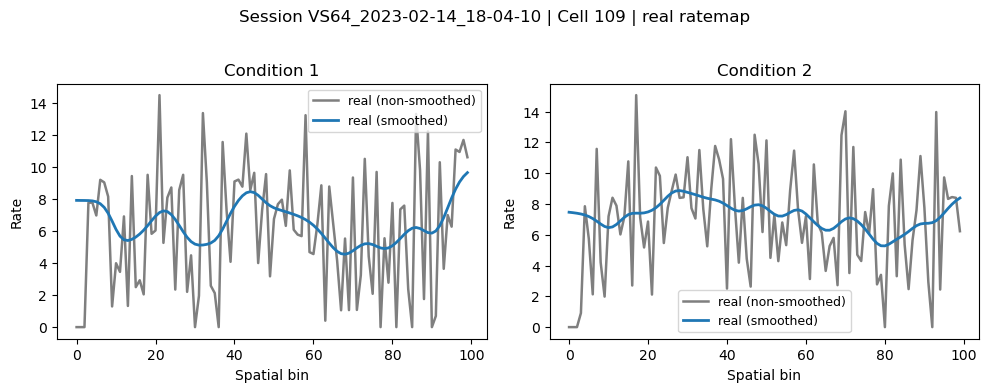

In [37]:
# Plot the real ratemap (non-smoothed vs smoothed) for the selected cell
rmap_cands = sorted((REPO_ROOT / 'results' / 'ratemap').rglob(f'{SESSION_ID}_rmap.npz'))
if not rmap_cands:
    raise FileNotFoundError(f'No ratemap file found for {SESSION_ID} under {REPO_ROOT / "results" / "ratemap"}')
rmap_path = rmap_cands[-1]
print('Using rmap:', rmap_path)

with np.load(rmap_path, allow_pickle=False) as z:
    rmap_cell_ids = z['cell_ids'].astype(np.int64)
    fr_raw_cx = z['rmap__fr_cx_ux'].astype(np.float64)
    fr_smooth_cx = z['rmap__fr_s_cx_ux'].astype(np.float64)

idx_rm = np.where(rmap_cell_ids == cid)[0]
if idx_rm.size == 0:
    raise KeyError(f'Cell id {cid} not found in ratemap file')
u_rm = int(idx_rm[0])

n_cond_rm = fr_raw_cx.shape[1]
if n_cond_rm != n_cond:
    print(f'Warning: condition mismatch (rmap={n_cond_rm}, pfnull={n_cond})')

n_cols_rm = min(3, n_cond_rm)
n_rows_rm = int(np.ceil(n_cond_rm / n_cols_rm))
fig, axes = plt.subplots(n_rows_rm, n_cols_rm, figsize=(5 * n_cols_rm, 3.8 * n_rows_rm), squeeze=False)
axes = axes.ravel()
x = np.arange(fr_raw_cx.shape[-1])

for c in range(n_cond_rm):
    ax = axes[c]
    ax.plot(x, fr_raw_cx[u_rm, c, :], color='#7f7f7f', linewidth=1.8, label='real (non-smoothed)')
    ax.plot(x, fr_smooth_cx[u_rm, c, :], color='#1f77b4', linewidth=2.0, label='real (smoothed)')
    ax.set_title(f'Condition {c+1}')
    ax.set_xlabel('Spatial bin')
    ax.set_ylabel('Rate')
    ax.legend(loc='best', fontsize=9)

for k in range(n_cond_rm, len(axes)):
    axes[k].axis('off')

fig.suptitle(f'Session {SESSION_ID} | Cell {cid} | real ratemap', y=1.02)
fig.tight_layout()
plt.show()


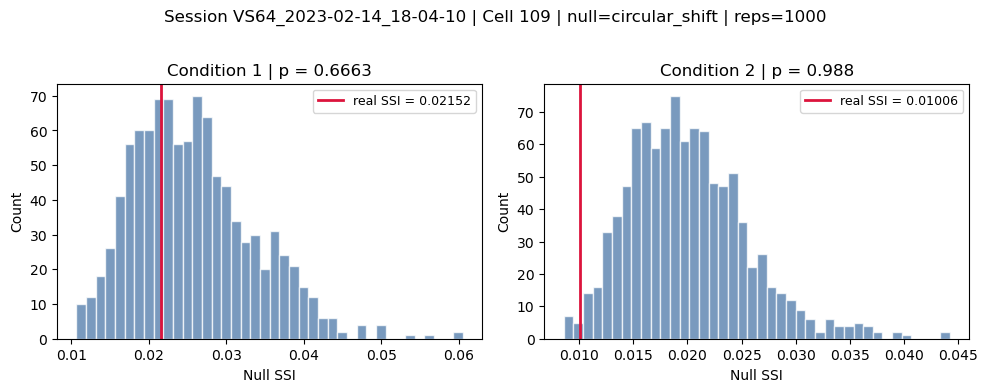

In [38]:
n_cond = ssi_obs.shape[1]
n_cols = min(3, n_cond)
n_rows = int(np.ceil(n_cond / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.8 * n_rows), squeeze=False)
axes = axes.ravel()

for c in range(n_cond):
    ax = axes[c]
    nd = ssi_null[u, c, :]
    nd = nd[np.isfinite(nd)]

    if nd.size == 0:
        ax.set_title(f'Cond {c+1}: no null data')
        ax.axis('off')
        continue

    real = float(ssi_obs[u, c])
    pval = float(ssi_pval[u, c])

    ax.hist(nd, bins=40, color='#4c78a8', alpha=0.75, edgecolor='white')
    ax.axvline(real, color='crimson', linewidth=2.0, label=f'real SSI = {real:.4g}')
    ax.set_title(f'Condition {c+1} | p = {pval:.4g}')
    ax.set_xlabel('Null SSI')
    ax.set_ylabel('Count')
    ax.legend(loc='best', fontsize=9)

for k in range(n_cond, len(axes)):
    axes[k].axis('off')

fig.suptitle(f'Session {SESSION_ID} | Cell {cid} | null={NULL_METHOD} | reps={NB_REP}', y=1.02)
fig.tight_layout()
plt.show()